# Notebook to run sweeps, save and load results

In [5]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
import os
#from main import *
import numpy as np
import matplotlib.pyplot as plt

## Learning rate

In [11]:
#Sweep Array:
sweep = [0.8,0.9,1.0,1.1,1.3,1.5,1.7] 
#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=64,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1648:  46%|████▌     | 400/875.0 [05:17<06:16,  1.26it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1648:  46%|████▌     | 400/875.0 [06:11<07:20,  1.08it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


...

Epoch 16.00/35 | Loss: 0.1651:  46%|████▌     | 400/875.0 [02:24<02:51,  2.77it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1655:  46%|████▌     | 400/875.0 [02:22<02:49,  2.81it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1655:  46%|████▌     | 400/875.0 [02:21<02:48,  2.83it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate=0.8  epochs= 16 loss=0.19447  train acc=0.9675  test acc=0.9700  317s
learning_rate=1.0  epochs= 16 loss=0.19505  train acc=0.9681  test acc=0.9700  207s
learning_rate=1.3  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  144s
learning_rate=1.5  epochs= 16 loss=0.19645  train acc=0.9681  test acc=0.9700  142s


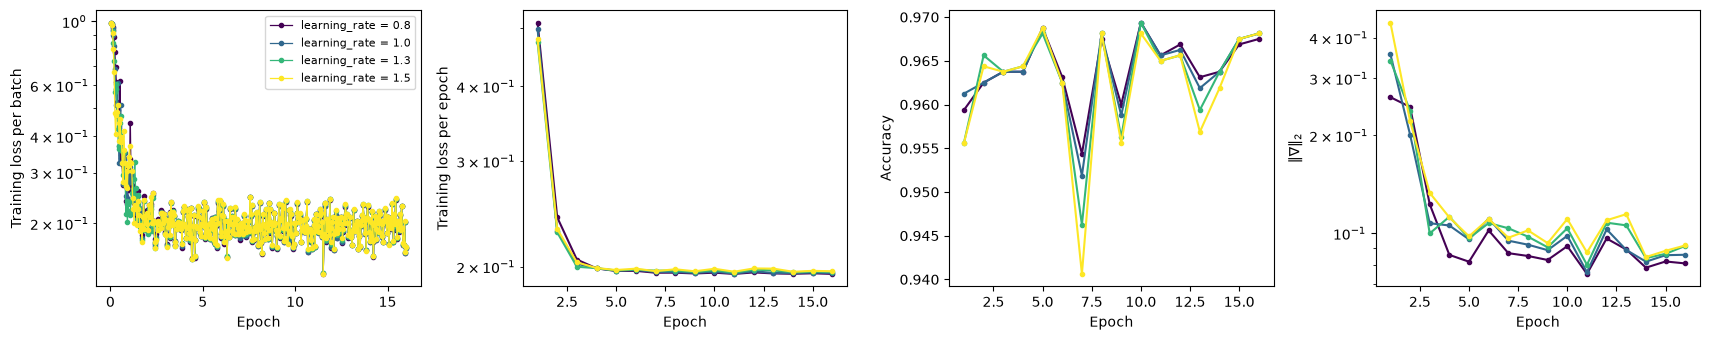

In [16]:
#%%All data
#Standard variables
init="haar"
sweep_label="learning_rate" 
m = 10
detector_positions = (33, 66)
sweep = [0.01, 0.03, 0.1, 0.3, 0.8,0.9,1.0,1.1,1.3,1.5,1.7,2.2,2.5,2.7,3,4,5.0,10.0,50.0] 
sweep = [0.3, 0.8,1.0,1.3,1.7,2.2,2.5,2.7]
sweep = [ 0.8,1.0,1.3,1.5] 

values=np.array([1,7])
trainers = []
E_tr, Y_tr, E_te, Y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_te, Y_te)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

#Plot trainingresults
fig, _ = plot_training(trainers, sweep, keys=("batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)



Learning Rate for bigger batch size

In [17]:
#Sweep Array:
sweep = [0.03,1.0,1.3,1.7,5,10] 

#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate_bigger_batchsize"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=256,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 35.00/35 | Loss: 0.4034: 100%|██████████| 245/245.0 [02:33<00:00,  1.60it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 27.00/35 | Loss: 0.1961:  77%|███████▋  | 189/245.0 [02:01<00:36,  1.55it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


...

Epoch 14.00/35 | Loss: 0.1872:  40%|████      | 98/245.0 [01:07<01:40,  1.46it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 13.00/35 | Loss: 0.9632:  37%|███▋      | 91/245.0 [01:03<01:47,  1.43it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.9076:  46%|████▌     | 112/245.0 [01:19<01:34,  1.41it/s]


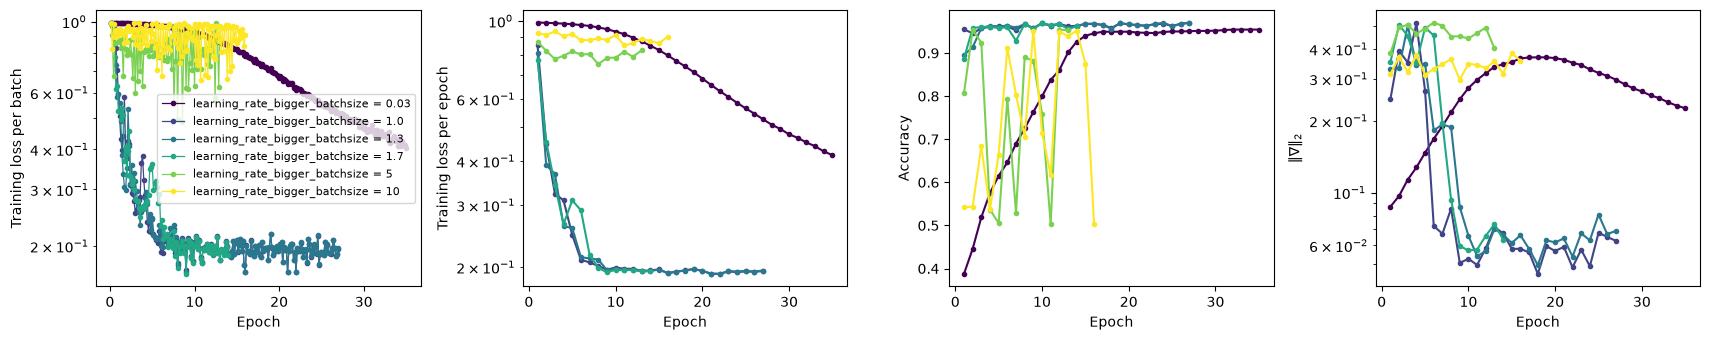

In [18]:
fig, _ = plot_training(trainers, sweep, keys=("batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)



Learning rate for smaller batch size

In [ ]:
#Sweep Array:
sweep = [0.03,1.0,1.3,1.7,5,10] 

#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate_bigger_batchsize"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=4,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.37/35 | Loss: 0.1658:  58%|█████▊    | 8147/14000.0 [25:15<18:56,  5.15it/s]  